# Preprocessing in scikit-learn

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

## What is it?

Preprocessing means **changing the numbers in a column before a model ever sees them**.
The rows stay the same. The columns stay the same. Only the *values* are rewritten.

Two jobs live under this one word:

| Job | What it fixes | Classes used here |
|---|---|---|
| **Scaling** | columns are measured in different units | `StandardScaler`, `MinMaxScaler`, `RobustScaler` |
| **Encoding** | columns hold text, and models only read numbers | `LabelEncoder`, `OneHotEncoder` |

Two smaller helpers also appear: `Binarizer` (turn a number into 0 or 1) and
`Normalizer` (make every **row** the same length).

## Why do we need it?

Take two columns from a bank table:

```text
   age      -> 25, 34, 51, 62            range is about 40
   salary   -> 300000, 480000, 910000    range is about 600000
```

To a human these are just two facts about a customer. To a model that measures
**distance**, `salary` is roughly 15,000 times bigger than `age`. So the model reads
salary loudly and age barely at all. Age did not become unimportant — it just lost the
shouting match.

Scaling puts both columns on **one common ruler**, so the model can judge them on
merit instead of on unit size.

Backend analogy: this is **unit normalisation at the API boundary**. One service sends
milliseconds, another sends seconds. Before any logic runs, you convert both to the same
unit. Preprocessing is that conversion step, for tables.

## Which models care?

| Model family | Needs scaling? | Reason |
|---|---|---|
| Linear / Logistic Regression | **Yes** | the coefficients are tied to the units |
| KNN, K-Means, SVM | **Yes, badly** | they literally compute distance |
| PCA | **Yes** | it chases the direction of largest variance, and big units fake large variance |
| Neural networks | **Yes** | gradient descent converges much faster |
| DecisionTree, RandomForest, XGBoost | **No** | a tree only asks *"is this value above the split point?"*, and that answer never changes when you rescale |

## The map of this notebook

```text
   make 3 fake columns          →  look at them (KDE, bar)
             │
             ├── StandardScaler   (x - mean) / std          → centre 0, spread 1
             ├── MinMaxScaler     (x - min) / (max - min)   → squeezed into 0 … 1
             └── RobustScaler     (x - median) / IQR        → outliers ignored
             │
             ├── Binarizer        value > threshold ? 1 : 0
             └── Normalizer       works on ROWS, not columns
             │
   read encoding.csv             →  LabelEncoder  →  OneHotEncoder  →  final table
             │
   decision chart: when to use which
```

## The one rule to hold on to

Every scaler on this page **moves and stretches the number line. It never changes the
shape of the data.** A skewed column stays skewed. An outlier stays an outlier. Only the
ruler underneath the data changes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,Binarizer,Normalizer,OneHotEncoder,LabelEncoder

## The imports, one line at a time

Everything in `sklearn.preprocessing` follows the same contract you already met with
`train_test_split`: an **estimator** with two verbs.

```text
   .fit(X)          LOOK    read the column, remember a few numbers
   .transform(X)    APPLY   use those numbers to rewrite the column
   .fit_transform(X)        both, in one call — only ever on the TRAIN set
```

Whatever `fit` learned is stored on the object with a **trailing underscore**. No
underscore means you supplied it; underscore means the data taught it.

| Class | `fit` remembers | Output |
|---|---|---|
| `StandardScaler` | `mean_`, `scale_` (the std) | mean 0, std 1 |
| `MinMaxScaler` | `data_min_`, `data_max_` | 0 … 1 |
| `RobustScaler` | `center_` (median), `scale_` (IQR) | median 0, IQR 1 |
| `Binarizer` | **nothing** — it is stateless | 0 or 1 |
| `Normalizer` | **nothing** — it is stateless | each row has length 1 |
| `LabelEncoder` | `classes_` | one integer column |
| `OneHotEncoder` | `categories_` | one 0/1 column per label |

Two of these — `Binarizer` and `Normalizer` — learn nothing from the data, so calling
`.transform()` without `.fit()` works. Every other class will raise
`NotFittedError` if you skip `fit`.

Note the odd one out: **`LabelEncoder` takes a 1-D array**, not a table. Every other
class takes a 2-D `X`. That is a deliberate hint — it was written for the target `y`.


In [2]:
np.random.seed(5)
a = np.random.normal(0,2,10000)
b = np.random.normal(5,3,10000)
c = np.random.normal(-5,5,10000)

df = pd.DataFrame({"A":a, "B":b,"C":c})
df 

,A,B,C
0,0.882455,1.466990,-7.089363
1,-0.661740,0.571914,-3.105893
2,4.861542,7.828852,-1.039068
3,-0.504184,5.001904,-9.755722
4,0.219220,1.731128,-7.679528
...,...,...,...
9995,-0.068972,3.739968,-4.303864
9996,-2.167260,0.681434,-9.584910
9997,2.188712,9.860986,-9.986860
9998,0.595445,5.982577,-11.128039


## What this cell built

`np.random.normal(mean, std, size)` draws random numbers from a bell curve.

| Call | Centre (`mean`) | Spread (`std`) | Most values land between |
|---|---|---|---|
| `np.random.normal(0, 2, 10000)` → `A` | 0 | 2 | −6 and +6 |
| `np.random.normal(5, 3, 10000)` → `B` | 5 | 3 | −4 and +14 |
| `np.random.normal(-5, 5, 10000)` → `C` | −5 | 5 | −20 and +10 |

*(The "most values" column is mean ± 3 × std, which covers about 99.7% of a bell curve.)*

`np.random.seed(5)` fixes the random generator, so these 10,000 numbers are identical
every time the notebook runs. Without it, every re-run would produce a different
picture and none of the numbers quoted below would match.

This is a **deliberately unfair table**. Three columns, three different centres, three
different spreads — exactly the situation scaling was invented for.


In [3]:
# keep a clean, untouched copy of the raw data.
# the cells below overwrite `df` several times, and we will want the original back.
raw = df.copy()

raw.describe().round(2)

,A,B,C
count,10000.00,10000.00,10000.00
mean,-0.00,5.01,-4.95
std,2.00,3.02,5.01
min,-7.20,-6.00,-24.56
25%,-1.36,2.98,-8.32
50%,0.01,5.01,-5.02
75%,1.37,7.05,-1.53
max,7.22,15.88,14.02


### Reading the table

| Row | Meaning in plain words |
|---|---|
| `count` | how many values — 10,000 in each column, no missing data |
| `mean` | the centre of gravity |
| `std` | the average distance from the mean — the "spread" |
| `min` / `max` | the two most extreme values |
| `25%` / `50%` / `75%` | the quartiles. `50%` is the **median**, the middle value |

The three columns came out almost exactly as ordered: `A` sits at 0 with spread 2,
`B` at 5 with spread 3, `C` at −5 with spread 5.

Look at the `min` and `max` row. `A` lives inside roughly **−7 … +7**, while `C` stretches
across **−25 … +14**. Column `C` covers nearly three times more ground than `A`.
A distance-based model would treat `C` as three times more important, purely because
of that spread. Nothing about the data says it is.

> The `25%`, `50%` and `75%` numbers matter later — `RobustScaler` is built entirely
> out of them.


---

# 1. Looking at the data first

## What is a KDE plot?

**KDE** stands for *Kernel Density Estimate*. Ignore the name. In practice:

> A KDE plot is a **histogram with the bars replaced by one smooth line**.

A histogram chops the number line into bins and draws a bar for how many values fell
in each bin. A KDE does the same job but draws a curve, so you are not distracted by
where the bin edges happened to land.

## What does "density" on the y-axis mean?

This trips up almost everyone. The y-axis is **not** a count of rows.

The rule is: **the total area under the curve is always exactly 1.**

So density answers *"what fraction of the data sits per unit of x?"* — not
*"how many rows are here?"*. Two consequences follow, and both show up in this notebook:

1. A **narrow** column has to be **tall**, because the same area 1 is packed into a
   thin strip.
2. A **wide** column is **short**, because the same area 1 is spread thin.

That is why after `MinMaxScaler` squeezes everything into 0 … 1, the curves shoot up to
a height of about 3. The data did not become more common. The x-axis just got shorter,
so the curve had to get taller to keep the area at 1.


<Axes: ylabel='Density'>

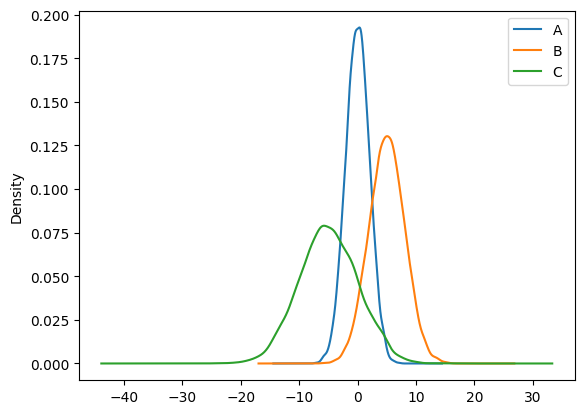

In [4]:
df.plot.kde()

### Reading the learner's own chart

Three separate humps, sitting at three different places, with three different widths.
Nothing is wrong with the data — this is simply what "different units" looks like.

The next two cells look at the same three columns more closely before any scaling
happens.


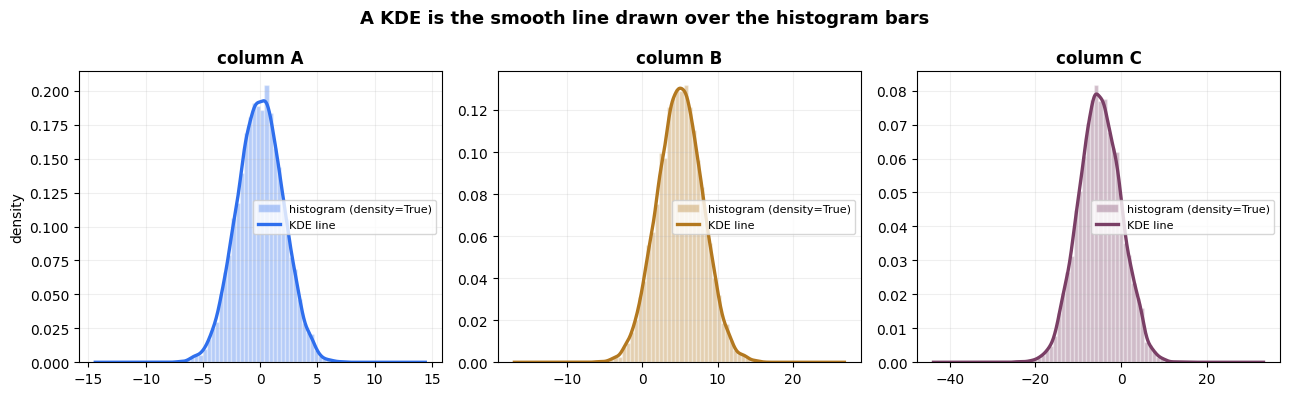

In [5]:
# proof that a KDE is just a smoothed histogram.
# `density=True` makes the histogram use the same y-axis scale as the KDE line.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = {"A": "#2f6fed", "B": "#b3781f", "C": "#7a3f66"}

for ax, col in zip(axes, raw.columns):
    ax.hist(raw[col], bins=40, density=True, color=colors[col], alpha=0.35,
            edgecolor="white", label="histogram (density=True)")
    raw[col].plot.kde(ax=ax, color=colors[col], lw=2.4, label="KDE line")
    ax.set_title(f"column {col}", fontweight="bold")
    ax.grid(alpha=0.2)
    ax.set_ylabel("")
    ax.legend(fontsize=8)

axes[0].set_ylabel("density")
fig.suptitle("A KDE is the smooth line drawn over the histogram bars",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The bars and the line tell the same story. From here on only the line is drawn,
because three lines fit on one chart and three sets of bars do not.

Now the same three columns on one pair of axes, with the mean and spread written on:


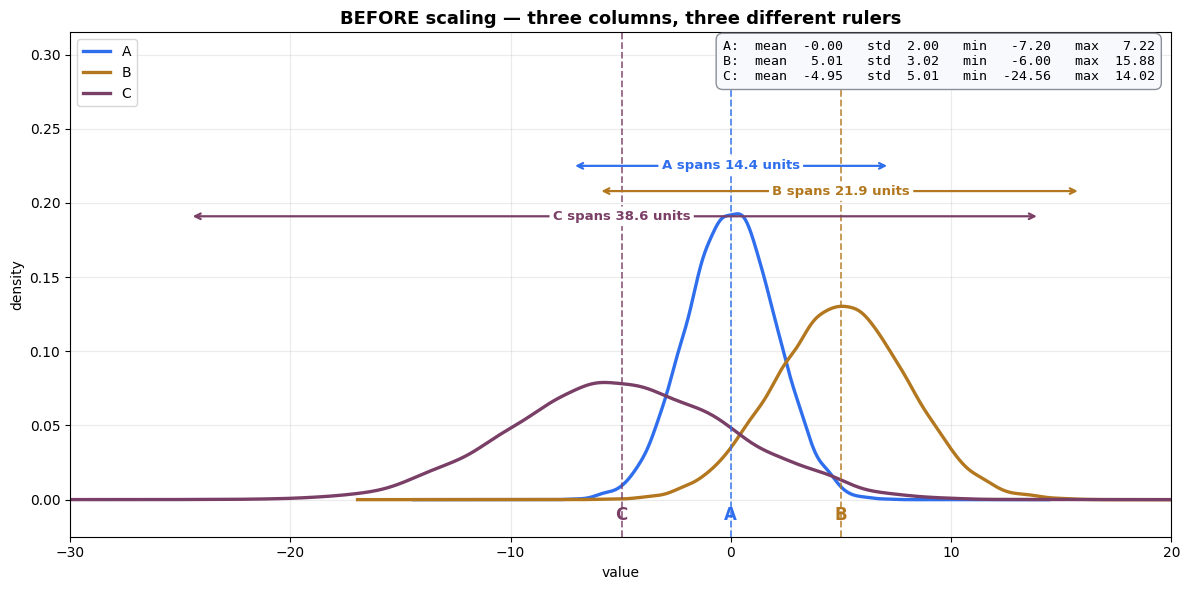

In [6]:
# the "before" picture, annotated the way it would be drawn on a whiteboard
fig, ax = plt.subplots(figsize=(12, 6))
raw.plot.kde(ax=ax, color=["#2f6fed", "#b3781f", "#7a3f66"], lw=2.4)

# a double-headed arrow per column, showing how much of the axis it claims
for i, col in enumerate(raw.columns):
    y = 0.225 - i * 0.017
    ax.annotate("", xy=(raw[col].min(), y), xytext=(raw[col].max(), y),
                arrowprops=dict(arrowstyle="<->", lw=1.6, color=colors[col]))
    ax.text(raw[col].mean(), y, f"{col} spans {raw[col].max() - raw[col].min():.1f} units",
            ha="center", va="center", fontsize=9.5, color=colors[col], fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none"))

# the mean of each column, marked on the axis
lines = []
for col in raw.columns:
    m = raw[col].mean()
    ax.axvline(m, color=colors[col], ls="--", lw=1.3, alpha=0.8)
    ax.annotate(f"{col}", xy=(m, 0), xytext=(m, -0.014), ha="center",
                fontsize=12, fontweight="bold", color=colors[col])
    lines.append(f"{col}:  mean {m:6.2f}   std {raw[col].std():5.2f}   "
                 f"min {raw[col].min():7.2f}   max {raw[col].max():6.2f}")

ax.text(0.985, 0.985, "\n".join(lines), transform=ax.transAxes, ha="right", va="top",
        family="monospace", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.5", fc="#f7f9fc", ec="#8a8f98"))

ax.set_xlim(-30, 20)
ax.set_ylim(-0.025, 0.315)
ax.legend(loc="upper left")
ax.set_title("BEFORE scaling \u2014 three columns, three different rulers",
             fontsize=13, fontweight="bold")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### What the picture says

Three curves, three different places on the x-axis, three different widths.

- `A` is **tall and narrow** — its values are packed tightly around 0.
- `C` is **short and wide** — the same 10,000 values are spread over three times more ground.

The double-headed arrows measure how much of the number line each column claims.
That difference in claimed width is the entire problem. A model does not know that
`C` is "naturally" wider. It only sees that `C` produces bigger differences between
rows, and concludes `C` matters more.

**The goal of the next few cells:** put all three curves on top of each other, so
no column wins by unit size alone.


---

## The bar-chart question in the next cell

The comment in the cell asks the right question, so here is the full answer.

**What `df.plot.bar()` does:** it draws **one rectangle per value**. The table has
10,000 rows × 3 columns, so Matplotlib is asked to draw and place **30,000 rectangles**,
then label 10,000 ticks on the x-axis. That is the 24 seconds.

**Why it is the wrong chart here:** a bar chart is for **categories** — a handful of
named things you want to compare, like sales per region. Its x-axis is a list of labels.

This data has no labels. It has 10,000 continuous measurements. The right chart for
that is a histogram or a KDE, which **summarise** the values instead of drawing every
one of them.

| You have | Right chart |
|---|---|
| a few named categories | `plot.bar()` |
| many continuous values | `plot.hist()` or `plot.kde()` |
| values over time | `plot.line()` |
| two continuous columns | `plot.scatter()` |

Run the cell once to see the effect, then use the cell after it instead.


<Axes: >

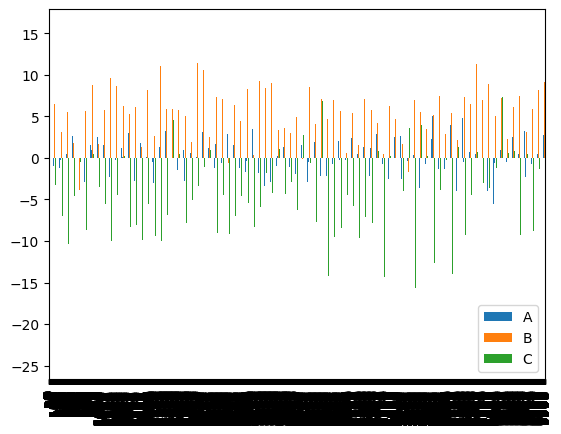

In [7]:
df.plot.bar() # What is this plot and why it takes time for 24 sec to render

### The same intent, drawn correctly

If the goal was *"show me the individual values"*, then show a **few** of them.
If the goal was *"show me the whole column"*, then summarise it.


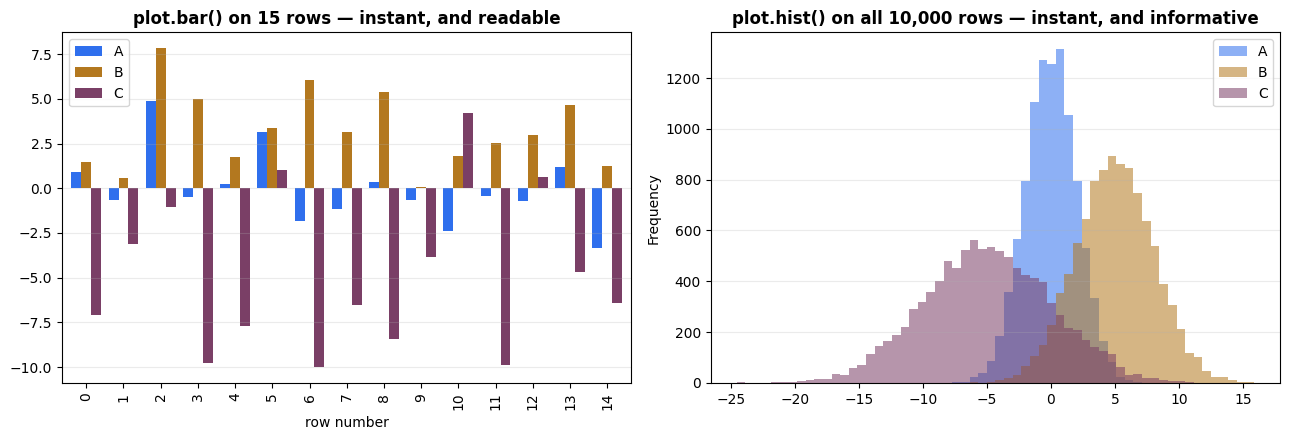

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: a bar chart used properly — few rows, so each bar is readable
raw.head(15).plot.bar(ax=axes[0], color=["#2f6fed", "#b3781f", "#7a3f66"], width=0.8)
axes[0].set_title("plot.bar() on 15 rows — instant, and readable", fontweight="bold")
axes[0].set_xlabel("row number")
axes[0].grid(axis="y", alpha=0.25)

# right: the whole column, summarised instead of drawn value by value
raw.plot.hist(ax=axes[1], bins=60, alpha=0.55,
              color=["#2f6fed", "#b3781f", "#7a3f66"])
axes[1].set_title("plot.hist() on all 10,000 rows — instant, and informative",
                  fontweight="bold")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

---

# 2. The three scalers

All three scalers on this page have the **same shape**:

$$x' = \frac{x - \text{centre}}{\text{spread}}$$

Subtract something to **move** the data, then divide by something to **stretch or
squeeze** it. They only disagree about which two numbers to use:

| Scaler | Centre it subtracts | Spread it divides by | Result |
|---|---|---|---|
| `StandardScaler` | mean $\mu$ | standard deviation $\sigma$ | mean 0, std 1 |
| `MinMaxScaler` | minimum $x_{min}$ | range $x_{max} - x_{min}$ | every value in 0 … 1 |
| `RobustScaler` | median $Q_2$ | $IQR = Q_3 - Q_1$ | median 0, IQR 1 |

That is the whole topic. Everything below is detail about **which pair to pick**.

---

## 2.1 StandardScaler — the z-score

> 📘 From the whiteboard: $\;z = \dfrac{x - \mu}{\sigma}\;$ with the boxed result
> $\;\mu = 0,\; \sigma \rightarrow 1$

$$z = \frac{x - \mu}{\sigma}$$

| Symbol | Name | Plain meaning |
|---|---|---|
| $x$ | the value | one cell in the column |
| $\mu$ (mu) | mean | the centre of the column |
| $\sigma$ (sigma) | standard deviation | the average distance from that centre |
| $z$ | z-score | **how many standard deviations away from the mean this value is** |

### Read it in two steps

1. **$x - \mu$ moves the column** so its centre lands on 0.
   A value above the mean becomes positive, below the mean becomes negative.
2. **$\div\, \sigma$ rescales the column** so that "one unit" now means
   "one standard deviation".

After both steps, a value of `2.0` means *"two standard deviations above average"* —
**in every column, regardless of what the column originally measured**. That is the
point. Salary and age end up speaking the same language.

The whiteboard drawing of the ruler is exactly right: the data does not move, the
**measuring tape** underneath it is replaced.

### What it does not do

It does **not** make the data a bell curve. If the column was skewed before, it is
still skewed after, just re-labelled. The name "standardise" misleads people here.

### Range

There is **no fixed range**. Most values land in −3 … +3, but an outlier can land at
+50 and nothing stops it.


<Axes: ylabel='Density'>

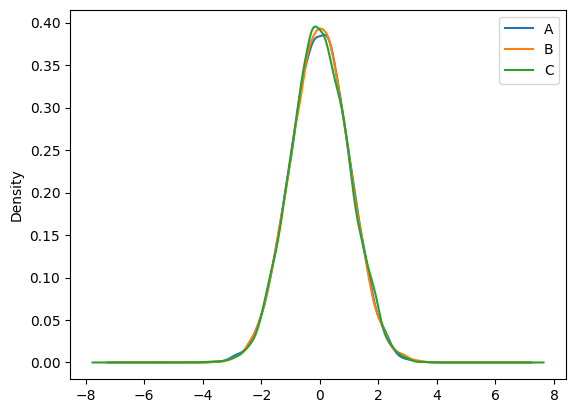

In [9]:
scaler = StandardScaler() 
scaled = scaler.fit_transform(df)

df = pd.DataFrame(scaled,columns=['A','B','C'])
df.plot.kde()

### What just happened to the picture

Compare it with the "before" chart. The three curves have **moved on top of each other**.

- All three now peak at **0** — because $x - \mu$ pushed each centre to zero.
- All three now have the **same width** — because $\div\, \sigma$ gave each one a
  spread of 1.
- The peak height jumped from about `0.19` to about `0.40`. Nothing became more common.
  Column `A` was squeezed from a 14-unit span into a 7-unit span, so the curve had to
  grow taller to keep the area at 1.

The three columns are now **comparable**. That is the only thing scaling ever promises.

> ⚠️ Note that this cell rebinds `df`. From here on `df` holds **scaled** data, and the
> next two cells receive it. Whether that matters is answered in section 2.4 — the
> answer is genuinely surprising.


In [10]:
# what did .fit() actually store?
scaler_demo = StandardScaler().fit(raw)

print("mean_   (the μ it subtracts) :", scaler_demo.mean_.round(4))
print("scale_  (the σ it divides by):", scaler_demo.scale_.round(4))
print()

# do the formula by hand, then check it against sklearn
manual = (raw - raw.mean()) / raw.std(ddof=0)      # ddof=0 -> population std, what sklearn uses
sk     = scaler_demo.transform(raw)

print("manual (x - μ) / σ  matches sklearn :", np.allclose(manual.values, sk))
print()

after = pd.DataFrame(sk, columns=raw.columns)
print("after StandardScaler")
print("  mean :", after.mean().round(10).tolist(), "  -> 0")
print("  std  :", after.std(ddof=0).round(10).tolist(), "  -> 1")
print("  min  :", after.min().round(2).tolist())
print("  max  :", after.max().round(2).tolist(), "  <- NOT bounded")

mean_   (the μ it subtracts) : [-6.0000e-04  5.0106e+00 -4.9549e+00]
scale_  (the σ it divides by): [2.0017 3.0158 5.0075]

manual (x - μ) / σ  matches sklearn : True

after StandardScaler
  mean : [-0.0, 0.0, 0.0]   -> 0
  std  : [1.0, 1.0, 1.0]   -> 1
  min  : [-3.59, -3.65, -3.91]
  max  : [3.61, 3.61, 3.79]   <- NOT bounded


### One trap worth knowing

`raw.std()` in Pandas divides by $n-1$. `StandardScaler` divides by $n$.
That is why the manual line above passes `ddof=0`.

With 10,000 rows the difference is invisible. With 10 rows it is not. If a hand check
ever disagrees with sklearn by a hair, this is usually the reason.


---

## 2.2 MinMaxScaler — squeeze into a fixed box

> 📘 From the whiteboard: $\;x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}\;$
> with the worked example $\;5 - 2 = 3$

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

| Symbol | Plain meaning |
|---|---|
| $x_{min}$ | the smallest value **in that column** |
| $x_{max}$ | the largest value **in that column** |
| $x_{max} - x_{min}$ | the range — the full width of the column |

### Read it in two steps

1. **$x - x_{min}$** slides the column so the smallest value sits at **0**.
2. **$\div\,(x_{max} - x_{min})$** shrinks the column so the largest value lands on **1**.

Everything else falls proportionally in between. The whiteboard's column of ticks
with $x_{min}$ marked at the bottom and $x_{max}$ at the top is precisely this: the
scaler reads only those two numbers off the column and ignores the other 9,998.

### Worked example, using the whiteboard's numbers

Column = `[2, 3, 5]`, so $x_{min} = 2$, $x_{max} = 5$, range $= 5 - 2 = 3$.

| $x$ | $x - 2$ | $\div\, 3$ | result |
|---|---|---|---|
| 2 | 0 | 0 / 3 | **0.00** |
| 3 | 1 | 1 / 3 | **0.33** |
| 5 | 3 | 3 / 3 | **1.00** |

The smallest value always becomes exactly 0. The largest always becomes exactly 1.

### The weakness, stated up front

The formula uses **only the two most extreme values in the column**. One wrong value —
a typo, a sensor spike, a `9999` used as a missing-data marker — sets $x_{max}$ all by
itself, and then all the real data gets crushed into a sliver near 0. Section 2.6
shows this happening.

### Where it is still the right choice

- **Images.** Pixels are already 0 … 255, so dividing into 0 … 1 is natural and there
  are no outliers by definition.
- **Neural networks.** Bounded inputs keep activation functions in their useful range.
- Any time a downstream step **requires** a fixed range.


<Axes: ylabel='Density'>

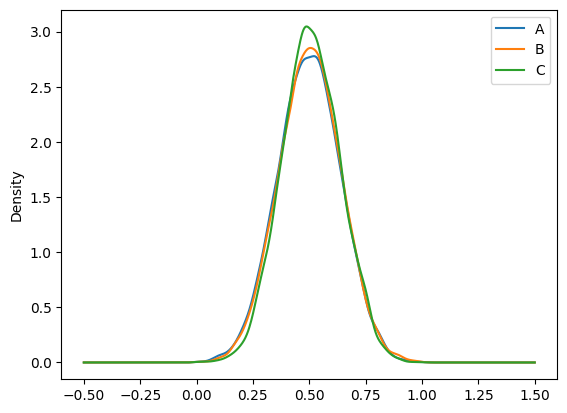

In [11]:
minimax = MinMaxScaler()
mm_scaled = minimax.fit_transform(df)

df = pd.DataFrame(mm_scaled,columns=["A",'B',"C"])
df.plot.kde()

### What just happened

Look at the x-axis: it now runs from **0 to 1**, exactly as promised. Every value in
every column is inside that box.

Look at the y-axis: the peak jumped to about **3.0**. Same reason as before. The data
was compressed into a 1-unit-wide box, so the density curve had to grow tall to keep
its area at 1. **A tall KDE peak means a narrow x-axis, never "more data".**

And the shape is still the same bell. Moving and squeezing cannot change shape.


In [12]:
# what did .fit() actually store?
mm_demo = MinMaxScaler().fit(raw)

print("data_min_ :", mm_demo.data_min_.round(3))
print("data_max_ :", mm_demo.data_max_.round(3))
print("data_range_ (max - min) :", mm_demo.data_range_.round(3))
print()

manual = (raw - raw.min()) / (raw.max() - raw.min())
sk     = mm_demo.transform(raw)
print("manual (x - min) / (max - min) matches sklearn :", np.allclose(manual.values, sk))
print()

after = pd.DataFrame(sk, columns=raw.columns)
print("after MinMaxScaler")
print("  min :", after.min().round(6).tolist(), "  -> exactly 0")
print("  max :", after.max().round(6).tolist(), "  -> exactly 1")
print()

# the whiteboard's own worked example, checked
tiny = np.array([[2.], [3.], [5.]])
print("whiteboard example [2, 3, 5] ->", MinMaxScaler().fit_transform(tiny).ravel().round(4))

data_min_ : [ -7.196  -6.002 -24.558]
data_max_ : [ 7.225 15.884 14.023]
data_range_ (max - min) : [14.42  21.886 38.581]

manual (x - min) / (max - min) matches sklearn : True

after MinMaxScaler
  min : [0.0, 0.0, 0.0]   -> exactly 0
  max : [1.0, 1.0, 1.0]   -> exactly 1

whiteboard example [2, 3, 5] -> [0.     0.3333 1.    ]


---

## 2.3 RobustScaler — the one that ignores outliers

> 📘 From the whiteboard: labelled **RS**, drawn against a bell curve with the
> extreme values circled at both tails —
> $\;x' = \dfrac{x - Q_2}{IQR}$

$$x' = \frac{x - Q_2}{IQR} \qquad\text{where}\qquad IQR = Q_3 - Q_1$$

### The two new words

Sort the column from smallest to largest and cut it into four equal piles:

```text
   smallest  ────────────────────────────────────────────  largest
             │           │            │            │
            min         Q1           Q2           Q3        max
                        25%         50%          75%
                                  MEDIAN
                         └──────── IQR ──────────┘
                            the middle 50% of the data
```

| Term | Plain meaning |
|---|---|
| $Q_1$ | the value 25% of the way up the sorted column |
| $Q_2$ | the **median** — the middle value |
| $Q_3$ | the value 75% of the way up |
| $IQR$ | $Q_3 - Q_1$ — how wide the **middle half** of the data is |

### Why this beats mean and std when outliers exist

Take `[1, 2, 3, 4, 5]` and change the last value to `1000`.

| Statistic | Before | After | Moved? |
|---|---|---|---|
| mean | 3.0 | 202.0 | **destroyed** |
| std | 1.41 | 399.0 | **destroyed** |
| median ($Q_2$) | 3.0 | 3.0 | **unchanged** |
| IQR | 2.0 | 2.0 | **unchanged** |

The median is a **position**, not a total. Dragging one value to infinity moves the
middle of the queue by at most one place. The mean is a total, so one huge value drags
it anywhere.

`RobustScaler` is built entirely from positions. That is the whole idea.

### Range

Like `StandardScaler`, there is **no fixed range**. Outliers still exist after scaling
— they land far out, which is exactly what you want. **A scaler is not an outlier
remover.** The whiteboard circles those tail values for a reason: they are still there
afterwards. `RobustScaler` only stops them from distorting *the other 99% of the rows*.


<Axes: ylabel='Density'>

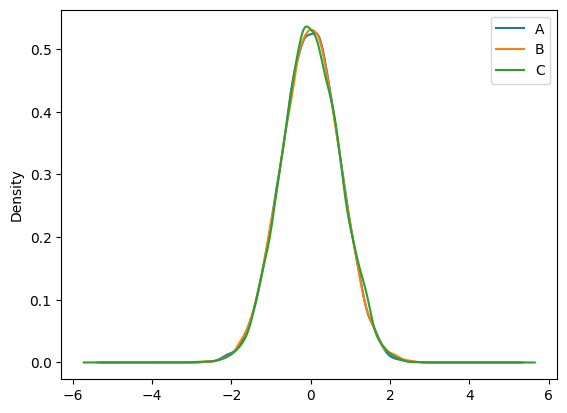

In [13]:
rscaler = RobustScaler()
robust = rscaler.fit_transform(df)
df = pd.DataFrame(robust, columns=['A','B','C'])
df.plot.kde()

### What just happened

The curves are centred on 0 again, and the x-axis runs to roughly ±3.

On *this* data — clean, symmetric, no outliers — the result looks a lot like
`StandardScaler`. That is expected. For a perfect bell curve, $IQR \approx 1.35\,\sigma$,
so the two scalers differ only by a constant factor.

**The difference between them only appears when outliers appear.** Section 2.6 adds
three of them and the two scalers stop agreeing immediately.


In [14]:
# what did .fit() actually store?
rs_demo = RobustScaler().fit(raw)

print("center_ (the median Q2 it subtracts) :", rs_demo.center_.round(4))
print("scale_  (the IQR it divides by)      :", rs_demo.scale_.round(4))
print()

q1 = raw.quantile(0.25)
q2 = raw.quantile(0.50)
q3 = raw.quantile(0.75)
print("Q1 :", q1.round(4).tolist())
print("Q2 :", q2.round(4).tolist(), "  <- median, matches center_")
print("Q3 :", q3.round(4).tolist())
print("IQR = Q3 - Q1 :", (q3 - q1).round(4).tolist(), "  <- matches scale_")
print()

manual = (raw - q2) / (q3 - q1)
print("manual (x - Q2) / IQR matches sklearn :", np.allclose(manual.values, rs_demo.transform(raw)))
print()

# the "one bad value" demo from the notes above, run for real
clean_col = np.array([[1.], [2.], [3.], [4.], [5.]])
dirty_col = np.array([[1.], [2.], [3.], [4.], [1000.]])
for name, col in [("clean [1,2,3,4,5]", clean_col), ("dirty [1,2,3,4,1000]", dirty_col)]:
    print(f"{name:24s} mean={col.mean():8.2f}  std={col.std():8.2f}"
          f"  median={np.median(col):5.2f}  IQR={np.percentile(col,75)-np.percentile(col,25):5.2f}")

center_ (the median Q2 it subtracts) : [ 0.0124  5.0121 -5.0212]
scale_  (the IQR it divides by)      : [2.7274 4.0721 6.7854]

Q1 : [-1.3573, 2.9752, -8.3152]
Q2 : [0.0124, 5.0121, -5.0212]   <- median, matches center_
Q3 : [1.3701, 7.0473, -1.5298]
IQR = Q3 - Q1 : [2.7274, 4.0721, 6.7854]   <- matches scale_

manual (x - Q2) / IQR matches sklearn : True

clean [1,2,3,4,5]        mean=    3.00  std=    1.41  median= 3.00  IQR= 2.00
dirty [1,2,3,4,1000]     mean=  202.00  std=  399.00  median= 3.00  IQR= 2.00


---

## 2.4 Wait — the three cells above fed each other. Does that break the comparison?

This is worth a whole section, because the honest answer is **no, and the reason is
useful**.

### What actually happened

Each of the three cells rebinds the name `df`, so:

```text
   the DataFrame cell    df = raw
   the StandardScaler cell   df = StandardScaler().fit_transform(df)   ← on raw
   the MinMaxScaler cell     df = MinMaxScaler().fit_transform(df)     ← on the STANDARDISED data
   the RobustScaler cell     df = RobustScaler().fit_transform(df)     ← on the MIN-MAX data
```

So the MinMax chart was not drawn from the raw data. It was drawn from data that had
already been standardised. By every instinct that should have corrupted the comparison.

### Why it did not

All three scalers have the form $x' = \dfrac{x - a}{b}$, where $a$ and $b$ are
**recomputed from whatever data they are handed**. A transform of that form is called
**affine** — a shift plus a stretch.

Feed an already-shifted-and-stretched column into a second affine scaler, and the
second scaler measures its own $a$ and $b$ *from that shifted data*. The two effects
cancel exactly. Written out for MinMax on standardised input:

$$\frac{z - z_{min}}{z_{max} - z_{min}}
= \frac{\frac{x-\mu}{\sigma} - \frac{x_{min}-\mu}{\sigma}}{\frac{x_{max}-\mu}{\sigma} - \frac{x_{min}-\mu}{\sigma}}
= \frac{x - x_{min}}{x_{max} - x_{min}}$$

The $\mu$ cancels in the subtraction and the $\sigma$ cancels in the division. The
result is identical to running `MinMaxScaler` on the raw column. The next cell proves
it numerically rather than asking you to trust the algebra.


In [15]:
# rebuild the exact chain the three scaler cells above created
chain_std    = StandardScaler().fit_transform(raw)
chain_mm     = MinMaxScaler().fit_transform(chain_std)     # minmax applied to standardised data
chain_robust = RobustScaler().fit_transform(chain_mm)      # robust applied to min-maxed data

# and the fair version: each scaler applied straight to the raw data
direct_std    = StandardScaler().fit_transform(raw)
direct_mm     = MinMaxScaler().fit_transform(raw)
direct_robust = RobustScaler().fit_transform(raw)

print("chained result == direct result ?")
print("  StandardScaler :", np.allclose(chain_std,    direct_std))
print("  MinMaxScaler   :", np.allclose(chain_mm,     direct_mm),
      "   max difference:", np.abs(chain_mm - direct_mm).max())
print("  RobustScaler   :", np.allclose(chain_robust, direct_robust),
      "   max difference:", np.abs(chain_robust - direct_robust).max())

chained result == direct result ?
  StandardScaler : True
  MinMaxScaler   : True    max difference: 2.220446049250313e-16
  RobustScaler   : True    max difference: 1.3322676295501878e-15


`True` on all three, with differences around `1e-16` — that is floating-point dust,
not a real difference.

### So when *would* this pattern be a real bug?

Three situations, and all three show up in real projects:

| Situation | Does the chain still cancel? |
|---|---|
| A **non-affine** step in between — `np.log`, `PowerTransformer`, `QuantileTransformer` | **No.** Those bend the shape, and nothing downstream can undo it. |
| **`fit` on train, `transform` on test** | **No.** The second scaler's $a$ and $b$ come from the train set, so they do not cancel against the test set's own min and max. |
| You still need the original values later | **No** — the name `df` was overwritten, and the raw numbers are gone. |

### The habit to take away

Give each result its own name. It costs one word and removes the whole question:

```python
df_std    = pd.DataFrame(StandardScaler().fit_transform(raw), columns=raw.columns)
df_minmax = pd.DataFrame(MinMaxScaler().fit_transform(raw),   columns=raw.columns)
df_robust = pd.DataFrame(RobustScaler().fit_transform(raw),   columns=raw.columns)
```

Backend analogy: this is the same reason you return a **new** DTO from a mapper instead
of mutating the request object in place. It worked here. It stops working the moment
someone inserts a step in the middle.

That is exactly what the next section does — three separate names, all fed from `raw`.


---

## 2.5 The fair side-by-side comparison

Three scalers, all fed the **same raw data**, drawn on one page.


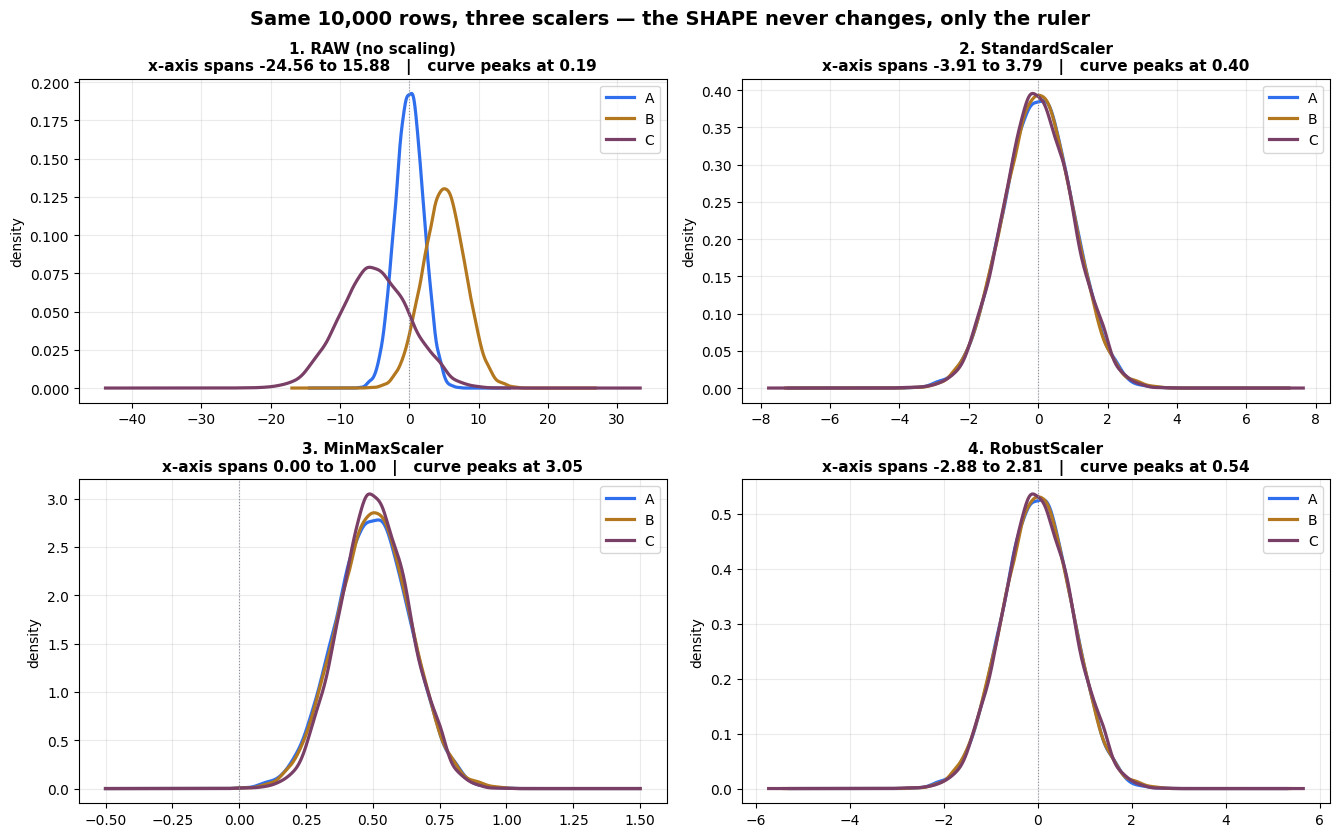

In [16]:
# every scaler fed from `raw` — no chaining, each result gets its own name
views = {
    "1. RAW (no scaling)": raw,
    "2. StandardScaler":   pd.DataFrame(StandardScaler().fit_transform(raw), columns=raw.columns),
    "3. MinMaxScaler":     pd.DataFrame(MinMaxScaler().fit_transform(raw),   columns=raw.columns),
    "4. RobustScaler":     pd.DataFrame(RobustScaler().fit_transform(raw),   columns=raw.columns),
}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))
for ax, (name, d) in zip(axes.ravel(), views.items()):
    d.plot.kde(ax=ax, color=["#2f6fed", "#b3781f", "#7a3f66"], lw=2.3)
    lo, hi = d.min().min(), d.max().max()
    peak = max(line.get_ydata().max() for line in ax.get_lines())
    ax.set_title(f"{name}\nx-axis spans {lo:.2f} to {hi:.2f}   |   curve peaks at {peak:.2f}",
                 fontweight="bold", fontsize=11)
    ax.grid(alpha=0.25)
    ax.set_ylabel("density")
    ax.axvline(0, color="#8a8f98", lw=0.8, ls=":")

fig.suptitle("Same 10,000 rows, three scalers — the SHAPE never changes, only the ruler",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Read the four panels together

| Panel | Where the curves sit | What changed |
|---|---|---|
| **RAW** | three separate humps | nothing yet — `C` claims three times more axis than `A` |
| **StandardScaler** | one hump at 0, width 1 | centres aligned, spreads equalised |
| **MinMaxScaler** | one hump inside 0 … 1 | everything forced into a box |
| **RobustScaler** | one hump at 0, width ≈ 1.35 | centres aligned using the median instead |

Three things to notice:

1. **In panels 2, 3 and 4 the three coloured curves lie on top of each other.**
   Before scaling they did not. That is the job, done.
2. **The bell shape is identical in all four panels.** Only the numbers on the x-axis
   changed. Scaling is a relabelling of the axis, nothing more.
3. **The peak height rises as the x-axis shrinks.** Raw peaks near 0.19, `RobustScaler`
   near 0.54, `MinMaxScaler` near 3.0. Area stays 1, so a narrow curve must be tall.

The next cell prints the same comparison as numbers.


In [17]:
# the same four panels, as a table
rows = []
for name, d in views.items():
    rows.append({
        "view":   name,
        "mean":   round(d.values.mean(), 3),
        "std":    round(d.values.std(), 3),
        "min":    round(d.values.min(), 3),
        "max":    round(d.values.max(), 3),
        "median": round(float(np.median(d.values)), 3),
        "IQR":    round(float(np.percentile(d.values, 75) - np.percentile(d.values, 25)), 3),
    })

pd.DataFrame(rows).set_index("view")

,mean,std,min,max,median,IQR
view,,,,,,
1. RAW (no scaling),0.018,5.411,-24.558,15.884,0.426,6.483
2. StandardScaler,0.000,1.000,-3.915,3.790,-0.003,1.357
3. MinMaxScaler,0.503,0.136,0.000,1.000,0.503,0.184
4. RobustScaler,0.002,0.738,-2.879,2.807,-0.000,1.002


Each scaler puts a **1** and a **0** exactly where its formula promised:

- `StandardScaler` → `mean` 0, `std` 1. The other columns are free.
- `MinMaxScaler` → `min` 0, `max` 1. The other columns are free.
- `RobustScaler` → `median` 0, `IQR` 1. The other columns are free.

Read the table that way and there is nothing left to memorise. **Each scaler
guarantees exactly the two numbers in its own formula, and makes no promise about
anything else.**


### The same idea on five numbers

10,000 rows make a nice curve but hide the arithmetic. Here are five values you can
check by hand, on four rulers.


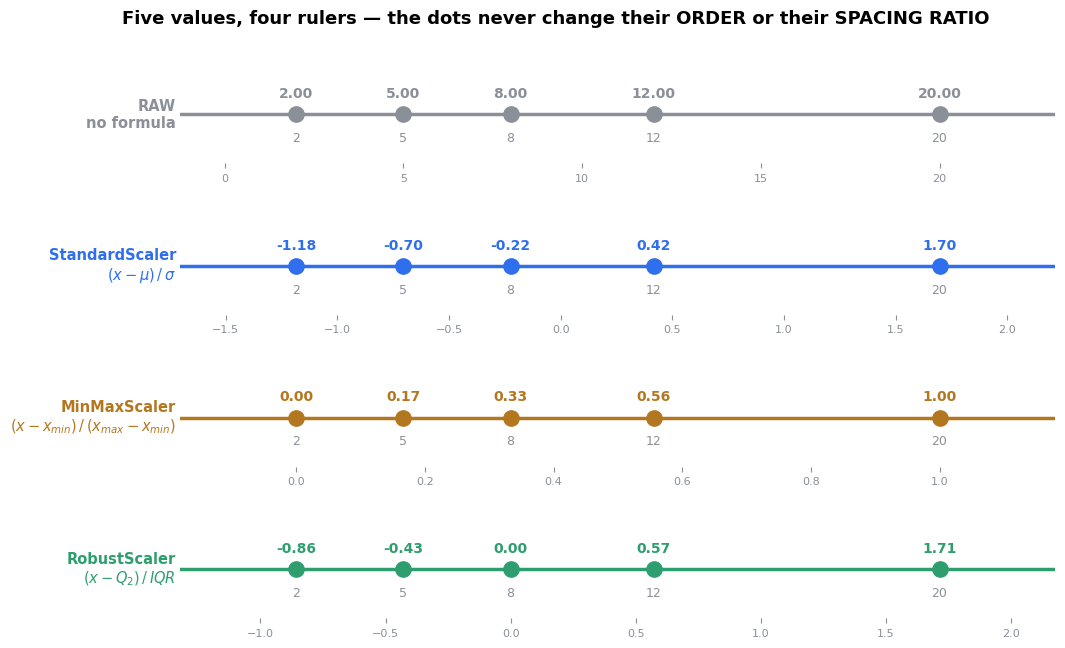

In [18]:
# five values, four rulers — the whiteboard version
vals = np.array([[2.], [5.], [8.], [12.], [20.]])

rulers = [
    ("RAW",             vals.ravel(),                                    "no formula",                    "#8a8f98"),
    ("StandardScaler",  StandardScaler().fit_transform(vals).ravel(),     r"$(x - \mu)\,/\,\sigma$",       "#2f6fed"),
    ("MinMaxScaler",    MinMaxScaler().fit_transform(vals).ravel(),       r"$(x - x_{min})\,/\,(x_{max}-x_{min})$", "#b3781f"),
    ("RobustScaler",    RobustScaler().fit_transform(vals).ravel(),       r"$(x - Q_2)\,/\,IQR$",           "#2f9e6f"),
]

fig, axes = plt.subplots(4, 1, figsize=(12.5, 7))
for ax, (name, v, formula, c) in zip(axes, rulers):
    pad = (v.max() - v.min()) * 0.18
    ax.axhline(0, color=c, lw=2.5)
    ax.plot(v, np.zeros_like(v), "o", ms=11, color=c, zorder=3)
    for original, scaled in zip(vals.ravel(), v):
        ax.annotate(f"{scaled:.2f}", xy=(scaled, 0), xytext=(scaled, 0.35),
                    ha="center", fontsize=10, fontweight="bold", color=c)
        ax.annotate(f"{original:.0f}", xy=(scaled, 0), xytext=(scaled, -0.55),
                    ha="center", fontsize=9, color="#8a8f98")
    ax.set_xlim(v.min() - pad, v.max() + pad)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.text(-0.005, 0.5, f"{name}\n{formula}", transform=ax.transAxes,
            ha="right", va="center", fontsize=10.5, fontweight="bold", color=c)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#8a8f98")

fig.suptitle("Five values, four rulers — the dots never change their ORDER or their SPACING RATIO",
             fontsize=13, fontweight="bold")
fig.subplots_adjust(left=0.20, top=0.90, hspace=0.55)
plt.show()

### The check to do by hand

Take the value **8** (the middle dot):

| Scaler | Arithmetic | Result |
|---|---|---|
| StandardScaler | $\mu = 9.4$, $\sigma = 6.25$ → $(8 - 9.4)/6.25$ | −0.22 |
| MinMaxScaler | $x_{min}=2$, $x_{max}=20$ → $(8 - 2)/(20 - 2)$ | 0.33 |
| RobustScaler | $Q_2 = 8$, $IQR = 12 - 5 = 7$ → $(8 - 8)/7$ | 0.00 |

Four completely different numbers for the same value. But look at the picture:
**the dots keep the same order and the same relative spacing on every ruler.** The gap
from 2 to 5 stays proportionally the gap it always was.

That is the visual proof that scaling **carries no information away**. It is a change
of units, like converting a price from rupees to dollars. The cheapest item is still
the cheapest item.


---

## 2.6 The test that separates the three scalers

Everything so far ran on clean, well-behaved data, where all three scalers looked
roughly interchangeable. Real data is not clean.

> 📘 The whiteboard drawing of a bell curve with the tail values **circled** is this
> exact scenario. Those circled points are outliers, and the question is what each
> scaler does when they are present.

The experiment: take the same 10,000 good rows and add **three** absurd values —
150, 160, 170, where the real data lives between −7 and +7. Then measure how much of
the axis the 10,000 good rows still occupy.


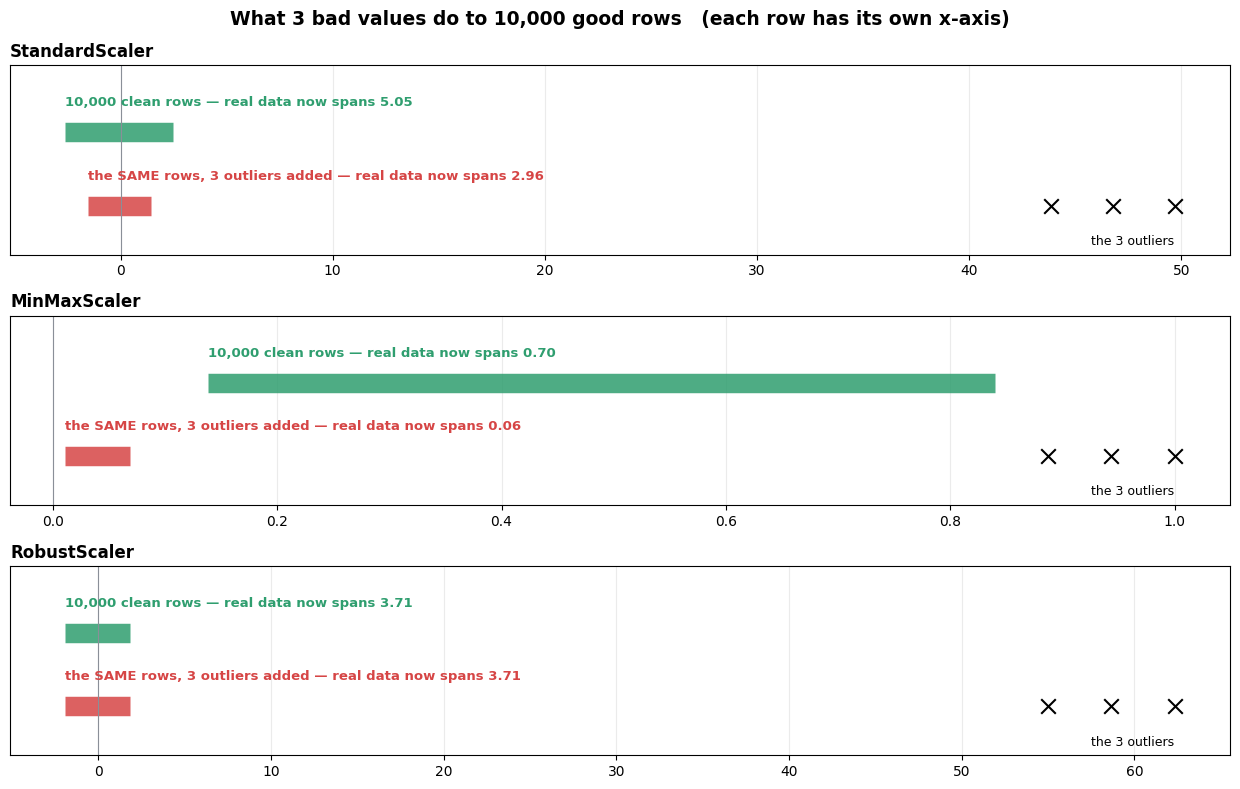

,span before,span after,shrunk by
scaler,,,
StandardScaler,5.055,2.958,1.7x
MinMaxScaler,0.702,0.057,12.3x
RobustScaler,3.710,3.709,1.0x


In [19]:
# 10,000 good rows, then the same rows with 3 absurd values bolted on
clean_data = raw[["A"]].values                                   # real range is about -7 .. +7
dirty_data = np.vstack([clean_data, [[150.], [160.], [170.]]])   # 3 nonsense readings

fig, axes = plt.subplots(3, 1, figsize=(12.5, 8))
summary = []

for ax, (name, Scaler) in zip(axes, [("StandardScaler", StandardScaler),
                                     ("MinMaxScaler",   MinMaxScaler),
                                     ("RobustScaler",   RobustScaler)]):
    a = Scaler().fit_transform(clean_data).ravel()          # fitted without outliers
    b = Scaler().fit_transform(dirty_data).ravel()          # fitted WITH outliers
    b_good = b[:len(clean_data)]                            # where the good rows landed

    for y, vals, label, c in [(1.0, a,      "10,000 clean rows",             "#2f9e6f"),
                              (0.4, b_good, "the SAME rows, 3 outliers added", "#d64545")]:
        lo, hi = np.percentile(vals, 0.5), np.percentile(vals, 99.5)
        ax.plot([lo, hi], [y, y], lw=14, color=c, solid_capstyle="butt", alpha=0.85)
        ax.text(lo, y + 0.19, f"{label} — real data now spans {hi - lo:.2f}",
                va="bottom", ha="left", fontsize=9.5, color=c, fontweight="bold")

    ax.scatter(b[len(clean_data):], [0.4] * 3, marker="x", s=110, color="black", zorder=5)
    ax.text(b[len(clean_data):].max(), 0.08, "the 3 outliers", fontsize=9, ha="right")

    before = np.percentile(a, 99.5) - np.percentile(a, 0.5)
    after  = np.percentile(b_good, 99.5) - np.percentile(b_good, 0.5)
    summary.append({"scaler": name, "span before": round(before, 3),
                    "span after": round(after, 3), "shrunk by": f"{before / after:.1f}x"})

    ax.set_yticks([]); ax.set_ylim(0, 1.55)
    ax.set_title(name, loc="left", fontweight="bold", fontsize=12)
    ax.axvline(0, color="#8a8f98", lw=0.8)
    ax.grid(axis="x", alpha=0.25)

fig.suptitle("What 3 bad values do to 10,000 good rows   (each row has its own x-axis)",
             fontsize=13.5, fontweight="bold")
plt.tight_layout()
plt.show()

pd.DataFrame(summary).set_index("scaler")

### The result, in one sentence each

| Scaler | What happened | Why |
|---|---|---|
| **StandardScaler** | the good rows lost about **40%** of their spread | three huge values pulled $\mu$ up and inflated $\sigma$ |
| **MinMaxScaler** | the good rows were crushed into about **8%** of the box | $x_{max}$ is now 170, so the real data is squeezed against 0 |
| **RobustScaler** | **no change at all** | the median and the IQR never noticed three values at the far end |

`MinMaxScaler` is the worst hit, and the reason is structural: its formula reads **only
the two most extreme values**. Those are precisely the values most likely to be wrong.

Look at the middle panel. Ten thousand real, meaningful, different customers now sit
in a band of width 0.06 — while three typos own the remaining 94% of the axis. Any
distance-based model looking at that column now sees ten thousand rows that are
effectively identical.

### The decision rule

> **Outliers in the column → `RobustScaler`. No outliers, and you need a fixed 0 … 1
> box → `MinMaxScaler`. Everything else → `StandardScaler`.**

And note what `RobustScaler` did *not* do: the three outliers are still sitting out
there at the right. **Scaling never removes an outlier.** If a value is genuinely wrong,
delete it or cap it *before* scaling. `RobustScaler` only stops it from wrecking the
other rows.


---

# 3. Binarizer — turning a number into a yes/no

$$x' = \begin{cases} 1 & \text{if } x > \text{threshold} \\ 0 & \text{if } x \le \text{threshold} \end{cases}$$

Note the boundary carefully: **strictly greater than** becomes 1. A value **equal to**
the threshold becomes **0**.

This is not scaling. It throws information away on purpose. `Binarizer` answers one
question per cell — *"is this above the line?"* — and discards everything else.

Where it earns its place:

- **"Did the customer buy anything at all?"** from a purchase-amount column.
- **"Was the page visited?"** from a visit-count column.
- Turning a grey image into a black-and-white mask.

`Binarizer` is **stateless**. It learns nothing from the data, because you supplied the
threshold yourself. That is why the next cell calls `.transform()` with no `.fit()`
first and it works.

The cell below uses `threshold=5`, so watch what the two `5`s in the matrix become.


In [20]:
binary = Binarizer(threshold=5)

a = np.array([[ 30, 10,  22],
              [ 20,  2,  10],
              [ 33,  5, 5]])

binary1 = binary.transform(a)
binary1

array([[1, 1, 1],
       [1, 0, 1],
       [1, 0, 0]])

### Checking the output cell by cell

```text
   input                 threshold = 5           output
   [30, 10, 22]          all three > 5           [1, 1, 1]
   [20,  2, 10]          2 is not > 5            [1, 0, 1]
   [33,  5,  5]          5 is not > 5            [1, 0, 0]
```

The two `5`s became **0**, not 1. `Binarizer` uses `>`, not `>=`. If you want `5` to
count as a pass, set `threshold=4.999` or subtract a hair from your cut-off.

One more detail: the threshold is a **single number applied to every column at once**.
There is no per-column threshold. If column 1 needs a cut-off of 5 and column 2 needs
1000, you need two `Binarizer`s inside a `ColumnTransformer`.


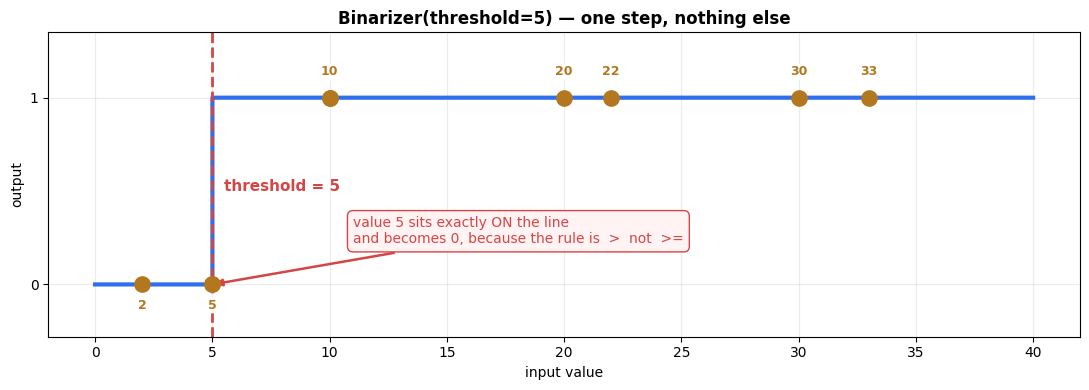

In [21]:
# what the threshold rule actually looks like
x = np.linspace(0, 40, 1000)
y = (x > 5).astype(int)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, y, lw=3, color="#2f6fed", drawstyle="steps-post")
ax.axvline(5, color="#d64545", ls="--", lw=2)
ax.text(5.5, 0.5, "threshold = 5", color="#d64545", fontsize=11, fontweight="bold")

# drop the 9 real values from the matrix onto the step
for value in a.ravel():
    ax.plot(value, int(value > 5), "o", ms=11, color="#b3781f", zorder=5)
    hit = int(value > 5)
    ax.annotate(f"{value}", xy=(value, hit), xytext=(value, hit + (0.12 if hit else -0.13)),
                ha="center", fontsize=9, fontweight="bold", color="#b3781f",
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none"))

ax.annotate("value 5 sits exactly ON the line\nand becomes 0, because the rule is  >  not  >=",
            xy=(5, 0), xytext=(11, 0.22), fontsize=10, color="#d64545",
            arrowprops=dict(arrowstyle="-|>", color="#d64545", lw=1.8),
            bbox=dict(boxstyle="round,pad=0.4", fc="#fff3f3", ec="#d64545"))

ax.set_yticks([0, 1])
ax.set_ylim(-0.28, 1.35)
ax.set_xlabel("input value")
ax.set_ylabel("output")
ax.set_title("Binarizer(threshold=5) — one step, nothing else", fontweight="bold", fontsize=12)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---

# 4. Normalizer — the one that works on ROWS

This is the single most misread class in `sklearn.preprocessing`, so it gets stated
loudly:

> **Every scaler so far worked down a COLUMN. `Normalizer` works across a ROW.**

```text
   StandardScaler / MinMaxScaler / RobustScaler        Normalizer
   ────────────────────────────────────────────        ──────────────────────────
        A     B     C                                       A     B     C
      ┌───┐ ┌───┐ ┌───┐                                  ┌─────────────────┐
      │ ↓ │ │ ↓ │ │ ↓ │   one column at a time           │ ────────────→   │  one row
      │ ↓ │ │ ↓ │ │ ↓ │   columns never mix              ├─────────────────┤  at a time
      │ ↓ │ │ ↓ │ │ ↓ │                                  │ ────────────→   │  columns DO mix
      └───┘ └───┘ └───┘                                  └─────────────────┘
```

## What it computes

For each row, divide every value in that row by the **length of the row**:

$$x'_i = \frac{x_i}{\sqrt{x_1^2 + x_2^2 + \dots + x_n^2}}$$

The bottom half is the **Euclidean length** of the row, also called the L2 norm — the
same $\sqrt{a^2 + b^2}$ you know from Pythagoras, just with more terms.

After dividing, **every row has length exactly 1**. The row keeps its *direction* and
loses its *size*.

## Why anyone would want that

The classic case is **text**. Two documents about the same subject should count as
similar even if one is 200 words and the other is 2,000. Raw word counts make the long
document look enormous. After `Normalizer`, only the *proportions* of words survive —
which is the thing you actually wanted to compare.

The next three cells build the formula by hand first, then check it against sklearn.


In [22]:
X = [[5, 2, 3],
     [2, 4, 10],
     [6, 8, 6]]

sss = [np.sqrt(np.sum(np.power(X[i], 2))) for i in range(len(X))]
len(X)

3

### Step 1 — the row lengths

`np.power(X[i], 2)` squares each value in row `i`, `np.sum` adds them, `np.sqrt` takes
the square root. That is the denominator of the formula, computed one row at a time.

| Row | Values | $\sqrt{\text{sum of squares}}$ | Length |
|---|---|---|---|
| 0 | 5, 2, 3 | $\sqrt{25 + 4 + 9} = \sqrt{38}$ | 6.164 |
| 1 | 2, 4, 10 | $\sqrt{4 + 16 + 100} = \sqrt{120}$ | 10.954 |
| 2 | 6, 8, 6 | $\sqrt{36 + 64 + 36} = \sqrt{136}$ | 11.662 |

Three rows, three very different lengths. Row 2 is nearly twice as "long" as row 0,
even though its values are not obviously more important.

*(The cell prints `len(X)` — that is just the row count, 3. The list `sss` holds the
three lengths.)*


In [23]:
np.array([X[k] / sss[k] for k in range(len(X))])

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

### Step 2 — divide each row by its own length

`X[k] / sss[k]` divides every value in row `k` by that row's length. NumPy broadcasts
the single number across the three values in the row.

Now check the first row: $5/6.164 = 0.811$, $2/6.164 = 0.324$, $3/6.164 = 0.487$.
And $0.811^2 + 0.324^2 + 0.487^2 = 1.0$.

Every row now has length 1. That is the whole transform, written out by hand.


In [24]:
normalizer = Normalizer()
data_tf = normalizer.fit_transform(X)
data_tf

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

### Step 3 — the same thing, from the library

Identical numbers. The hand-written version and `Normalizer()` agree to the last
decimal, which is the point of doing both.

`Normalizer` is **stateless**, like `Binarizer` — there is nothing to learn from the
data, because each row is handled entirely on its own. `fit()` exists only so the class
fits the estimator interface; it does nothing.

`norm='l2'` is the default and is the formula above. Two alternatives exist:

| `norm` | Divides by | Effect |
|---|---|---|
| `'l2'` | $\sqrt{\sum x_i^2}$ | row length becomes 1 (default) |
| `'l1'` | $\sum \lvert x_i \rvert$ | the row **sums** to 1 — the values become proportions |
| `'max'` | $\max \lvert x_i \rvert$ | the biggest value in the row becomes 1 |


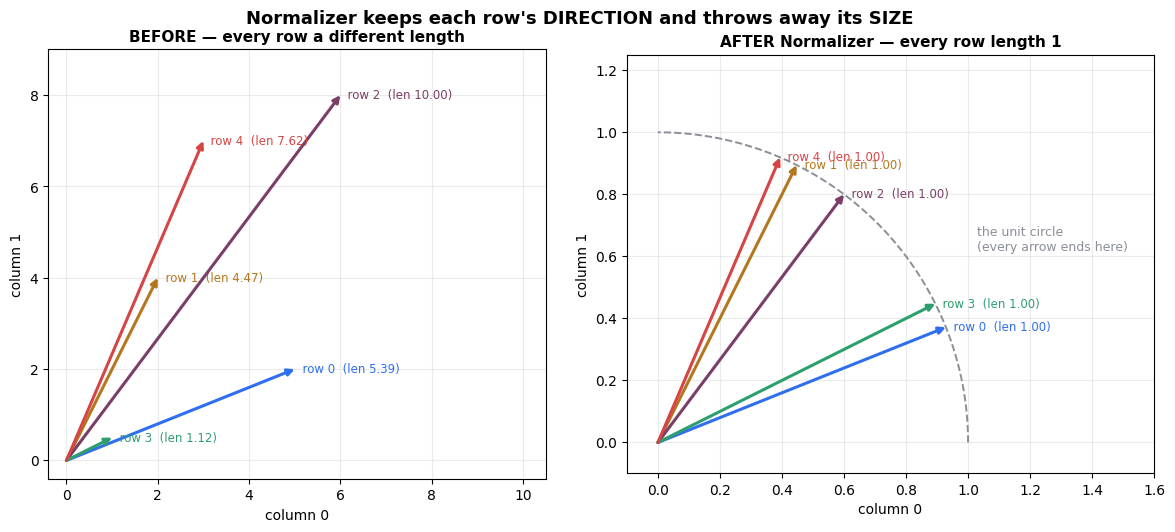

In [25]:
# why "length 1" is easier to see with two columns than three
pts = np.array([[5., 2.], [2., 4.], [6., 8.], [1., 0.5], [3., 7.]])
pts_n = Normalizer().fit_transform(pts)
arrow_colors = ["#2f6fed", "#b3781f", "#7a3f66", "#2f9e6f", "#d64545"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, (data, title, show_arc) in zip(axes, [(pts,   "BEFORE — every row a different length", False),
                                              (pts_n, "AFTER Normalizer — every row length 1", True)]):
    for i, (px, py) in enumerate(data):
        ax.annotate("", xy=(px, py), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=2.2, color=arrow_colors[i],
                                    shrinkA=0, shrinkB=0))
        ax.text(px, py, f"  row {i}  (len {np.hypot(px, py):.2f})", fontsize=8.5,
                color=arrow_colors[i], va="center")
    if show_arc:
        th = np.linspace(0, np.pi / 2, 200)
        ax.plot(np.cos(th), np.sin(th), ls="--", color="#8a8f98", lw=1.4)
        ax.text(1.03, 0.62, "the unit circle\n(every arrow ends here)",
                fontsize=9, color="#8a8f98")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("column 0")
    ax.set_ylabel("column 1")

axes[0].set_xlim(-0.4, 10.5); axes[0].set_ylim(-0.4, 9)
axes[1].set_xlim(-0.1, 1.6);  axes[1].set_ylim(-0.1, 1.25)

fig.suptitle("Normalizer keeps each row's DIRECTION and throws away its SIZE",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Every arrow keeps the angle it started with and gets trimmed to the dashed circle.

**The angle is the information Normalizer protects. The length is the information it
deletes.** If two rows pointed the same way before, they are now *the same point*.

That is why it suits text, and why it is wrong for something like `[age, salary]` — you
would be declaring that a 30-year-old earning ₹300,000 is identical to a 60-year-old
earning ₹600,000, because both rows point in the same direction.

### The rule

| You want to compare | Use |
|---|---|
| columns against each other | `StandardScaler` / `MinMaxScaler` / `RobustScaler` |
| rows against each other, by direction only | `Normalizer` |

They are not alternatives. They answer different questions, and a text pipeline often
uses both.


---

# 5. Encoding — turning text into numbers

Scaling fixed columns that were *numbers in the wrong units*. Encoding fixes columns
that are **not numbers at all**.

Every scikit-learn model multiplies its inputs by weights. `"Mumbai"` cannot be
multiplied. So before any model runs, every text column has to become numeric — and
**how** you do that changes what the model believes.

The file below has a `TEAM` column holding `A`, `B`, `C`, `D`.


In [26]:
dff = pd.read_csv("/Users/kaliprasad/Documents/MACHINE_LEARNING/AI_ML_Series/02_data_toolkit_apps/02_pandas/DataSet/encoding.csv")
dff

,TEAM,YEAR
0,A,2000
1,B,2002
2,C,2003
3,D,2004
4,A,2005
5,C,2006
6,B,2007
7,A,2008
8,D,2009


Nine rows, two columns. `TEAM` is text, `YEAR` is already a number.

`TEAM` has four distinct labels — `A`, `B`, `C`, `D` — and some of them repeat.
The number of distinct labels is called the **cardinality**, and it is the main thing
that decides which encoder to use.

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum*
>
> The path in the cell above is absolute, so the notebook only runs on this machine.
> A relative path — `"../02_pandas/DataSet/encoding.csv"` — works for anyone who clones
> the repository. Same idea as a classpath resource instead of `/home/me/config.yml`.


## 5.1 LabelEncoder — one number per label

`LabelEncoder` sorts the distinct labels alphabetically and hands out integers starting
at 0:

```text
   'A' → 0        'B' → 1        'C' → 2        'D' → 3
```

The mapping is stored in `le.classes_`, where the **integer is the position in that
array** — the same rule you met with `iris.target_names`.

Two things about the next cell are worth pausing on, and both are covered underneath it.


In [27]:
le = LabelEncoder()
df1 = dff
df1.TEAM = le.fit_transform(df1.TEAM)
df1

,TEAM,YEAR
0,0,2000
1,1,2002
2,2,2003
3,3,2004
4,0,2005
5,2,2006
6,1,2007
7,0,2008
8,3,2009


### Gotcha 1 — `df1 = dff` did not make a copy

```python
df1 = dff          # this does NOT copy anything
```

In Python, `=` binds a **new name to the same object**. `df1` and `dff` are now two
labels on one DataFrame. So `df1.TEAM = ...` also changed `dff`, and the original text
column is gone from both.

Backend analogy: `List<Row> b = a;` in Java. You did not clone the list; you now have
two references to it. `dff.copy()` is the `new ArrayList<>(a)` of Pandas.

Scroll up and re-run the `dff` cell — it prints numbers now, not letters.

### Gotcha 2 — `LabelEncoder` was not built for input columns

The class is documented as *"Encode target labels with value between 0 and n_classes-1"*.
**Target labels.** It takes a 1-D array, not a table, which is the API telling you the
same thing.

Using it on an input feature creates a problem the next section is entirely about.
The next cell shows what `fit` stored.


In [28]:
print("le.classes_ :", le.classes_)
print("the integer a label gets IS its index in that array:")
for i, label in enumerate(le.classes_):
    print(f"   position {i}  ->  '{label}'")
print()

# gotcha 1, demonstrated rather than asserted
print("df1 is dff  ->", df1 is dff, "  (two names, one object — that is why dff changed too)")
print()
print("dff now holds:")
print(dff.head(3))
print()

# going back from numbers to labels
print("inverse_transform([0, 1, 2, 3]) ->", le.inverse_transform([0, 1, 2, 3]))

le.classes_ : ['A' 'B' 'C' 'D']
the integer a label gets IS its index in that array:
   position 0  ->  'A'
   position 1  ->  'B'
   position 2  ->  'C'
   position 3  ->  'D'

df1 is dff  -> True   (two names, one object — that is why dff changed too)

dff now holds:
   TEAM  YEAR
0     0  2000
1     1  2002
2     2  2003

inverse_transform([0, 1, 2, 3]) -> ['A' 'B' 'C' 'D']


---

## 5.2 OneHotEncoder — and the problem it exists to solve

### The problem with the numbers we just created

After `LabelEncoder`, the `TEAM` column holds `0, 1, 2, 3`. A model does not know these
came from letters. It reads them as **quantities**, and quantities support arithmetic:

```text
   D (3)  >  C (2)  >  B (1)  >  A (0)      ← the model now believes team D is "more" than team A
   (A + C) / 2  =  1  =  B                  ← and that B is the average of A and C
   D - A  =  3      B - A  =  1             ← and that D is three times further from A than B is
```

Every one of those statements is invented. Nothing in the data says team D outranks
team A. `LabelEncoder` manufactured a **fake ordering**, and a linear model or a
distance-based model will use it.

### The fix

Give every label its **own column**, holding 1 if the row is that label and 0 otherwise:

```text
   TEAM            TEAM_A  TEAM_B  TEAM_C  TEAM_D
   ────            ──────  ──────  ──────  ──────
    A       →        1       0       0       0
    B       →        0       1       0       0
    C       →        0       0       1       0
    D       →        0       0       0       1
```

Now **every pair of labels is exactly the same distance apart**. No label is bigger than
another, because they no longer live on one axis. One column became four, and that is
the price.

### When *not* to one-hot

| Situation | Better choice |
|---|---|
| the labels have a **real order** (`low < medium < high`) | `OrdinalEncoder` — the order is genuine information, keep it |
| **hundreds** of distinct labels (pin codes, product IDs) | target / frequency encoding — one-hot would add hundreds of columns |
| you are training a **tree** model | trees split on `== value`, so the fake order does not hurt them much |

### About the next cell

`OneHotEncoder` returns a **sparse matrix** by default — a memory-saving format that
only stores the positions of the 1s. `.toarray()` converts it to a normal dense NumPy
array so Pandas can read it. Passing `sparse_output=False` to the constructor does the
same thing up front.

Also note `df1[['TEAM']]` with **double** brackets. `OneHotEncoder` needs a 2-D input.
Single brackets give a 1-D Series and raise an error.


In [29]:
enc = OneHotEncoder()
enc_df1 = pd.DataFrame(enc.fit_transform(df1[['TEAM']]).toarray())
enc_df1

,0,1,2,3
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0
7,1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0


Four columns for four teams, and exactly one `1` per row.

The column names came out as `0, 1, 2, 3`, which tells you nothing about which team is
which. `sklearn` can supply real names — the next cell shows that, and the `drop` option.


In [30]:
# `dff` was overwritten in the cell above (gotcha 1), so the letters are gone.
# re-read the file to get them back — and note the RELATIVE path this time.
fresh = pd.read_csv("../02_pandas/DataSet/encoding.csv")

enc_named = OneHotEncoder(sparse_output=False)
matrix = enc_named.fit_transform(fresh[["TEAM"]])

print("categories_             :", enc_named.categories_)
print("get_feature_names_out() :", enc_named.get_feature_names_out())
print()

named = pd.DataFrame(matrix, columns=enc_named.get_feature_names_out(), dtype=int)
print(named.head(4))
print()

# drop='first' — the "dummy variable trap" option
enc_drop = OneHotEncoder(sparse_output=False, drop="first")
dropped = pd.DataFrame(enc_drop.fit_transform(fresh[["TEAM"]]),
                       columns=enc_drop.get_feature_names_out(), dtype=int)
print("with drop='first' — 3 columns instead of 4:")
print(dropped.head(4))

categories_             : [array(['A', 'B', 'C', 'D'], dtype=object)]
get_feature_names_out() : ['TEAM_A' 'TEAM_B' 'TEAM_C' 'TEAM_D']

   TEAM_A  TEAM_B  TEAM_C  TEAM_D
0       1       0       0       0
1       0       1       0       0
2       0       0       1       0
3       0       0       0       1

with drop='first' — 3 columns instead of 4:
   TEAM_B  TEAM_C  TEAM_D
0       0       0       0
1       1       0       0
2       0       1       0
3       0       0       1


Now the columns are called `TEAM_A` … `TEAM_D`, which survive into the final table and
still mean something six months later.

### Why `drop='first'` exists

With all four columns present, the fourth is redundant: if `TEAM_A`, `TEAM_B` and
`TEAM_C` are all 0, the row **must** be team D. The four columns always add up to 1,
so one of them is fully predictable from the other three.

That perfect redundancy is called the **dummy variable trap**, and it makes a linear
model's coefficients unstable — there are infinitely many weight combinations that give
the same prediction, so the fitted numbers become meaningless individually.

| Model | Use `drop='first'`? |
|---|---|
| Linear / Logistic Regression, and anything reading coefficients | **yes** |
| Regularised models (Ridge, Lasso), trees, neural nets | not required — regularisation or the split rule handles it |


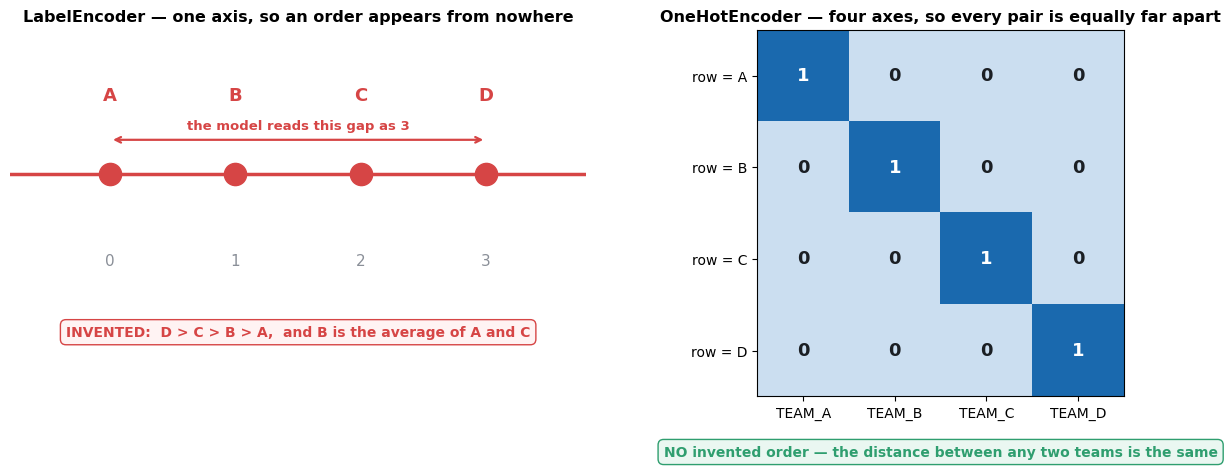

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# LEFT — LabelEncoder puts the four teams on one axis, which invents an order
ax = axes[0]
ax.axhline(0, color="#d64545", lw=2.5)
for i, label in enumerate(le.classes_):
    ax.plot(i, 0, "o", ms=16, color="#d64545", zorder=3)
    ax.annotate(f"{label}", xy=(i, 0), xytext=(i, 0.28), ha="center",
                fontsize=13, fontweight="bold", color="#d64545")
    ax.annotate(f"{i}", xy=(i, 0), xytext=(i, -0.35), ha="center", fontsize=11, color="#8a8f98")
ax.annotate("", xy=(3, 0.13), xytext=(0, 0.13),
            arrowprops=dict(arrowstyle="<->", lw=1.6, color="#d64545"))
ax.text(1.5, 0.17, "the model reads this gap as 3", ha="center", fontsize=9.5,
        color="#d64545", fontweight="bold")
ax.text(1.5, -0.62, "INVENTED:  D > C > B > A,  and B is the average of A and C",
        ha="center", fontsize=10, color="#d64545", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff3f3", ec="#d64545"))
ax.set_xlim(-0.8, 3.8); ax.set_ylim(-0.85, 0.55)
ax.set_yticks([]); ax.set_xticks([])
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_title("LabelEncoder — one axis, so an order appears from nowhere",
             fontweight="bold", fontsize=11.5)

# RIGHT — OneHotEncoder gives each team its own column, so all pairs are equidistant
ax = axes[1]
grid = np.eye(4)
ax.imshow(grid, cmap="Blues", vmin=-0.4, vmax=1.4)
for r in range(4):
    for c in range(4):
        ax.text(c, r, int(grid[r, c]), ha="center", va="center", fontsize=13,
                fontweight="bold", color="white" if grid[r, c] else "#1b1f24")
ax.set_xticks(range(4), [f"TEAM_{t}" for t in le.classes_], fontsize=10)
ax.set_yticks(range(4), [f"row = {t}" for t in le.classes_], fontsize=10)
ax.set_title("OneHotEncoder — four axes, so every pair is equally far apart",
             fontweight="bold", fontsize=11.5)
ax.text(1.5, 4.15, "NO invented order — the distance between any two teams is the same",
        ha="center", fontsize=10, color="#2f9e6f", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#eaf7f1", ec="#2f9e6f"))

plt.tight_layout()
plt.show()

In [32]:
abc = df1.join(enc_df1)
abc

,TEAM,YEAR,0,1,2,3
0,0,2000,1.0,0.0,0.0,0.0
1,1,2002,0.0,1.0,0.0,0.0
2,2,2003,0.0,0.0,1.0,0.0
3,3,2004,0.0,0.0,0.0,1.0
4,0,2005,1.0,0.0,0.0,0.0
5,2,2006,0.0,0.0,1.0,0.0
6,1,2007,0.0,1.0,0.0,0.0
7,0,2008,1.0,0.0,0.0,0.0
8,3,2009,0.0,0.0,0.0,1.0


### What `join` did

`df1.join(enc_df1)` glues the two tables side by side **by index**. Both have the
default `RangeIndex` `0…8`, so row 0 meets row 0 and everything lines up.

That alignment is not guaranteed in general. If `df1` had been filtered — say
`df1[df1.YEAR > 2004]` — its index would be `4,5,6,7,8` while the encoder output still
starts at 0, and `join` would produce `NaN` for the rows that do not match.

Safe habits: `.reset_index(drop=True)` on both sides before joining, or
`pd.concat([df1, enc_df1], axis=1)`, or skip the whole problem with a
`ColumnTransformer` (shown at the end of this notebook).


In [33]:
final = abc.drop(['TEAM'], axis='columns')
final

,YEAR,0,1,2,3
0,2000,1.0,0.0,0.0,0.0
1,2002,0.0,1.0,0.0,0.0
2,2003,0.0,0.0,1.0,0.0
3,2004,0.0,0.0,0.0,1.0
4,2005,1.0,0.0,0.0,0.0
5,2006,0.0,0.0,1.0,0.0
6,2007,0.0,1.0,0.0,0.0
7,2008,1.0,0.0,0.0,0.0
8,2009,0.0,0.0,0.0,1.0


### The finished table

The original `TEAM` column is dropped because its information now lives in the four
`0/1` columns. Keeping both would feed the model the same fact twice — once in the
honest form and once in the fake-ordered form.

`YEAR` is left untouched, and in a real pipeline it would still need scaling: values
around 2000 next to values of 0 and 1 is exactly the unit mismatch this notebook
started with.

**The full recipe for a mixed table:**

```text
   numeric columns  →  a scaler
   text columns     →  an encoder
   join the two halves back together
```

Doing that by hand is what the last four cells did. `ColumnTransformer` does it in one
object, and the closing section shows how.


---

# 6. When should I use which? — the decision chart

Everything above, as one picture.


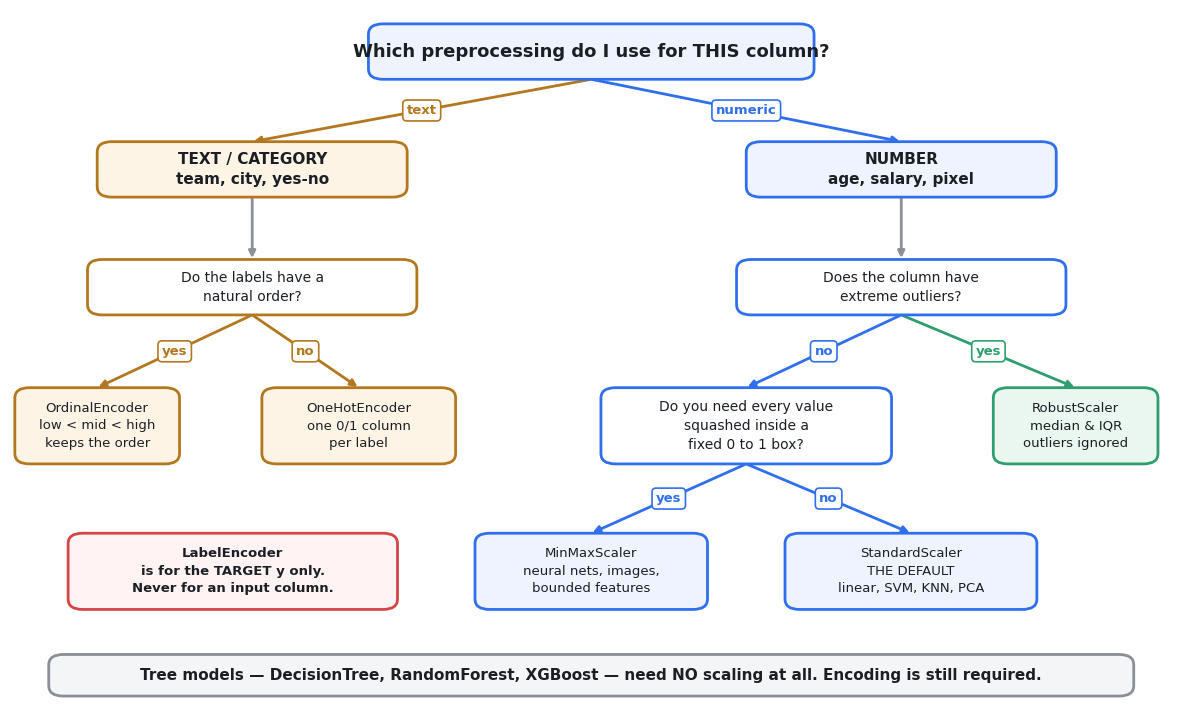

In [34]:
from matplotlib.patches import FancyBboxPatch

BLUE, BRASS, GREEN, RED, GREY = "#2f6fed", "#b3781f", "#2f9e6f", "#d64545", "#8a8f98"

fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 120); ax.set_ylim(0, 100); ax.axis("off")

def box(x, y, w, h, text, fc="#ffffff", ec=GREY, fs=10, bold=False):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0,rounding_size=1.5",
                                fc=fc, ec=ec, lw=2, zorder=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, zorder=3,
            fontweight="bold" if bold else "normal", color="#1b1f24", linespacing=1.45)
    return (x, y, w, h)

def arrow(a, b, label="", color=GREY):
    x1, y1, _, h1 = a
    x2, y2, _, h2 = b
    ax.annotate("", xy=(x2, y2 + h2 / 2), xytext=(x1, y1 - h1 / 2),
                arrowprops=dict(arrowstyle="-|>", lw=2, color=color, shrinkA=1, shrinkB=1), zorder=1)
    if label:
        ax.text((x1 + x2) / 2, (y1 - h1 / 2 + y2 + h2 / 2) / 2, label,
                ha="center", va="center", fontsize=9.5, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=1.2), zorder=4)

root = box(60, 94, 46, 8, "Which preprocessing do I use for THIS column?",
           fc="#eef3ff", ec=BLUE, bold=True, fs=13)
qcat = box(25, 77, 32, 8, "TEXT / CATEGORY\nteam, city, yes-no", fc="#fdf4e6", ec=BRASS, bold=True, fs=11)
qnum = box(92, 77, 32, 8, "NUMBER\nage, salary, pixel", fc="#eef3ff", ec=BLUE, bold=True, fs=11)
arrow(root, qcat, "text", BRASS)
arrow(root, qnum, "numeric", BLUE)

qord = box(25, 60, 34, 8, "Do the labels have a\nnatural order?", ec=BRASS)
qout = box(92, 60, 34, 8, "Does the column have\nextreme outliers?", ec=BLUE)
arrow(qcat, qord)
arrow(qnum, qout)

e1 = box(9, 40, 17, 11, "OrdinalEncoder\nlow < mid < high\nkeeps the order", fc="#fdf4e6", ec=BRASS, fs=9.5)
e2 = box(36, 40, 20, 11, "OneHotEncoder\none 0/1 column\nper label", fc="#fdf4e6", ec=BRASS, fs=9.5)
arrow(qord, e1, "yes", BRASS)
arrow(qord, e2, "no", BRASS)

s1 = box(110, 40, 17, 11, "RobustScaler\nmedian & IQR\noutliers ignored", fc="#eaf7f1", ec=GREEN, fs=9.5)
qbox = box(76, 40, 30, 11, "Do you need every value\nsquashed inside a\nfixed 0 to 1 box?", ec=BLUE)
arrow(qout, s1, "yes", GREEN)
arrow(qout, qbox, "no", BLUE)

s2 = box(60, 19, 24, 11, "MinMaxScaler\nneural nets, images,\nbounded features", fc="#eef3ff", ec=BLUE, fs=9.5)
s3 = box(93, 19, 26, 11, "StandardScaler\nTHE DEFAULT\nlinear, SVM, KNN, PCA", fc="#eef3ff", ec=BLUE, fs=9.5)
arrow(qbox, s2, "yes", BLUE)
arrow(qbox, s3, "no", BLUE)

box(23, 19, 34, 11, "LabelEncoder\nis for the TARGET y only.\nNever for an input column.",
    fc="#fff3f3", ec=RED, fs=9.5, bold=True)
box(60, 4, 112, 6,
    "Tree models — DecisionTree, RandomForest, XGBoost — need NO scaling at all. Encoding is still required.",
    fc="#f4f5f7", ec=GREY, fs=11, bold=True)

plt.show()

### The same chart as text

```mermaid
flowchart TD
    A[A column in your table] --> B{Is it a number?}

    B -- no, it is text --> C{Do the labels<br/>have a real order?}
    C -- yes, low &lt; mid &lt; high --> D[OrdinalEncoder]
    C -- no, just names --> E{How many<br/>distinct labels?}
    E -- a few --> F[OneHotEncoder]
    E -- hundreds --> G[target / frequency encoding]

    B -- yes, it is numeric --> H{Does the model<br/>care about scale?}
    H -- "no: tree, forest, XGBoost" --> I[leave it alone]
    H -- "yes: linear, SVM, KNN, PCA, NN" --> J{Are there<br/>extreme outliers?}
    J -- yes --> K[RobustScaler]
    J -- no --> L{Need a fixed<br/>0 to 1 range?}
    L -- "yes: images, neural nets" --> M[MinMaxScaler]
    L -- no --> N[StandardScaler]

    style D fill:#fdf4e6,stroke:#b3781f
    style F fill:#fdf4e6,stroke:#b3781f
    style G fill:#fdf4e6,stroke:#b3781f
    style I fill:#f4f5f7,stroke:#8a8f98
    style K fill:#eaf7f1,stroke:#2f9e6f
    style M fill:#eef3ff,stroke:#2f6fed
    style N fill:#eef3ff,stroke:#2f6fed
```

## The master table

| Class | Formula | Guarantees | Outlier-safe? | Works on | Reach for it when |
|---|---|---|---|---|---|
| `StandardScaler` | $(x-\mu)/\sigma$ | mean 0, std 1 | ❌ no | columns | **the default.** Linear/logistic, SVM, KNN, PCA, neural nets |
| `MinMaxScaler` | $(x-x_{min})/(x_{max}-x_{min})$ | min 0, max 1 | ❌ **worst** | columns | a fixed range is required — images, neural-net inputs |
| `RobustScaler` | $(x-Q_2)/IQR$ | median 0, IQR 1 | ✅ yes | columns | the column has outliers you cannot delete |
| `Binarizer` | $x > t \rightarrow 1$ else $0$ | values are 0 or 1 | n/a | cells | you only care *whether* something crossed a line |
| `Normalizer` | $x / \lVert x \rVert_2$ | every **row** has length 1 | n/a | **rows** | comparing rows by direction — text, TF-IDF |
| `LabelEncoder` | label → its index | integers 0…n−1 | n/a | 1-D `y` | encoding the **target**, never an input |
| `OneHotEncoder` | label → its own 0/1 column | no invented order | n/a | columns | a text input column with few distinct labels |

## Five mistakes to avoid

1. **Fitting the scaler on the whole dataset, then splitting.**
   The scaler's mean and min then contain information from the test rows. The score
   looks great and the deployed model disappoints. This is **data leakage**, and it is
   the most common way a beginner's model flatters itself. Split first, always.

2. **Calling `fit_transform` on the test set.**
   `fit_transform` on train, `transform` on test. Fitting again on test gives the test
   set its *own* mean and min, so train and test end up on two different rulers.

3. **Using `LabelEncoder` on an input column.**
   It invents an order that is not in the data. Use `OneHotEncoder` (no order) or
   `OrdinalEncoder` (a real order you specify).

4. **Reaching for `MinMaxScaler` by default.**
   It is the most fragile of the three. One bad value flattens the whole column, as
   section 2.6 measured.

5. **Expecting a scaler to fix skew or delete outliers.**
   It cannot. It only moves and stretches. For skew you need a *shape-changing*
   transform — `np.log1p`, `PowerTransformer`, `QuantileTransformer`.


---

# 7. The one habit that matters more than picking the right scaler

> 📘 **Split first. Fit the scaler on train only. Transform both.**

A scaler that computed its mean over the test rows has already seen the future.
The next cell measures how much of a difference that makes.


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(raw, test_size=0.2, random_state=42)

# WRONG — the scaler sees every row, including the ones it is about to be tested on
wrong = StandardScaler().fit(raw)

# RIGHT — the scaler only ever sees the training rows
right = StandardScaler().fit(X_train)

print("mean_ learned from ALL rows   :", wrong.mean_.round(5))
print("mean_ learned from TRAIN only :", right.mean_.round(5))
print("difference                    :", (wrong.mean_ - right.mean_).round(5))
print()
print("scale_ from ALL rows   :", wrong.scale_.round(5))
print("scale_ from TRAIN only :", right.scale_.round(5))
print()
print("The two rulers are different. On this clean synthetic data the gap is tiny,")
print("but on a small or skewed real dataset it is the difference between an honest")
print("score and a flattering one.")

mean_ learned from ALL rows   : [-5.90000e-04  5.01057e+00 -4.95491e+00]
mean_ learned from TRAIN only : [ 0.00616  5.00088 -4.96477]
difference                    : [-0.00675  0.00969  0.00987]

scale_ from ALL rows   : [2.0017  3.01579 5.00754]
scale_ from TRAIN only : [1.98886 2.99677 5.01382]

The two rulers are different. On this clean synthetic data the gap is tiny,
but on a small or skewed real dataset it is the difference between an honest
score and a flattering one.


### The version that cannot leak

`Pipeline` and `ColumnTransformer` remove the chance of getting this wrong, because
**the scaler lives inside the model object**. When you call `pipe.fit(X_train, y_train)`,
the scaler is fitted on the training fold only — every time, including inside
cross-validation, with no discipline required from you.

Backend analogy: this is dependency injection instead of `new`-ing a collaborator inside
a method. The wiring is declared once, and the object cannot be assembled wrongly.


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

# a small mixed table: two numeric columns and one text column
demo = pd.DataFrame({
    "age":    [25, 34, 51, 62, 29, 45, 38, 55],
    "salary": [300000, 480000, 910000, 1200000, 350000, 700000, 520000, 880000],
    "city":   ["Pune", "Mumbai", "Delhi", "Mumbai", "Pune", "Delhi", "Pune", "Mumbai"],
})
target = [0, 0, 1, 1, 0, 1, 0, 1]

# one object that says: scale these columns, one-hot those columns
prep = ColumnTransformer([
    ("numeric", StandardScaler(),                        ["age", "salary"]),
    ("text",    OneHotEncoder(handle_unknown="ignore"),  ["city"]),
])

pipe = Pipeline([
    ("prep",  prep),
    ("model", LogisticRegression()),
])

X_tr, X_te, y_tr, y_te = train_test_split(demo, target, test_size=0.25, random_state=0)

pipe.fit(X_tr, y_tr)          # <- the scaler is fitted on X_tr only. Leakage is impossible.
print("test accuracy :", pipe.score(X_te, y_te))
print()
print("columns produced by the preprocessing step:")
print(pipe.named_steps["prep"].get_feature_names_out())
print()
print("what the scaler inside the pipeline learned (from the TRAIN rows only):")
inner = pipe.named_steps["prep"].named_transformers_["numeric"]
print("  mean_  :", inner.mean_.round(2))
print("  scale_ :", inner.scale_.round(2))

test accuracy : 1.0

columns produced by the preprocessing step:
['numeric__age' 'numeric__salary' 'text__city_Delhi' 'text__city_Mumbai'
 'text__city_Pune']

what the scaler inside the pipeline learned (from the TRAIN rows only):
  mean_  : [4.1670000e+01 6.5166667e+05]
  scale_ : [1.3540000e+01 3.1603885e+05]


### Reading that output

`get_feature_names_out()` shows the full picture: `age` and `salary` came through the
scaler with their names intact, and `city` became three `0/1` columns. Two input
columns plus one text column became five numeric columns, and nothing was fitted on the
test rows.

The printed accuracy of `1.0` means nothing — the test set is two rows. The point of
the cell is the **wiring**, not the score.

`handle_unknown="ignore"` covers the case where a city appears in production that was
never in the training data. Without it, the encoder raises an error at exactly the worst
moment. With it, the unseen city becomes all zeros.

---

## Interview view

1. **"Why does scaling matter for KNN but not for a decision tree?"**
   KNN computes distance, so a column with bigger units contributes more to that
   distance. A tree only asks "is this value above the split point?", and the answer to
   that question is unchanged by any monotonic rescaling.

2. **"StandardScaler or MinMaxScaler?"**
   `StandardScaler` unless something downstream needs a bounded range — images, or a
   neural network. `MinMaxScaler` is the more fragile of the two because its formula
   depends only on the two most extreme values in the column.

3. **"What does `RobustScaler` do differently?"**
   It centres on the median instead of the mean and divides by the IQR instead of the
   standard deviation. Both of those are **positions in the sorted data**, so a handful
   of extreme values cannot move them.

4. **"Where exactly does data leakage creep in with a scaler?"**
   Calling `fit` (or `fit_transform`) on data that includes the test rows. The learned
   mean and range then encode information from rows the model is about to be scored on.
   A `Pipeline` makes this structurally impossible.

5. **"Why not just use `LabelEncoder` on every text column?"**
   It puts the labels on a single number line, which invents an order and a set of
   distances that the data never contained. A linear or distance-based model will use
   that invented structure. `OneHotEncoder` gives each label its own axis instead.

---

## Key takeaway

> **If you remember only one thing:** every scaler on this page is
> $x' = \dfrac{x - \text{centre}}{\text{spread}}$ — it **moves and stretches the number
> line, and never changes the shape of the data**. Pick the centre and spread by asking
> one question, *"does this column have outliers?"*: no → `StandardScaler`
> (or `MinMaxScaler` when you need a 0 … 1 box), yes → `RobustScaler`. Then fit it on
> the **training rows only**, ideally from inside a `Pipeline`, so it can never see the
> future.
